In [1]:
import pandas as pd
from sklearn.datasets import load_iris
# pip install scikit-learn matplotlib seaborn plotly

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### Exploratory Data Analysis

In [3]:
df.species.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
# statistical summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# checking for missing values
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [ ]:
# df.species.value_counts()

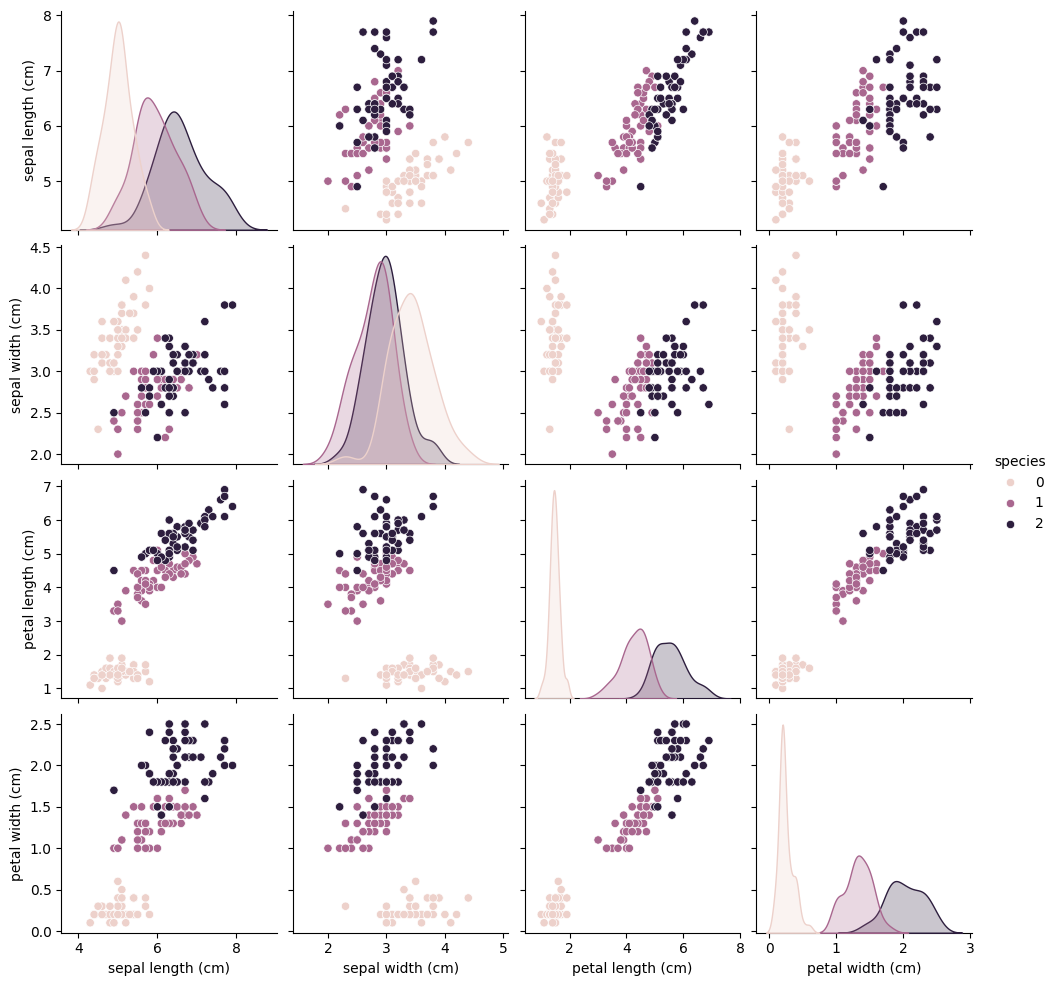

In [7]:
# visualizing feature distributions
import matplotlib.pyplot as plt
import seaborn as sns
# sns.pairplot creates a grid of scatter plots comparing each numeric feature against every other feature.
# Points are colored by species, making it easy to see how the species cluster in different feature combinations.
# Along the diagonal, you’ll see histograms of each feature, also colored by species.
sns.pairplot(df, hue="species")
plt.show()

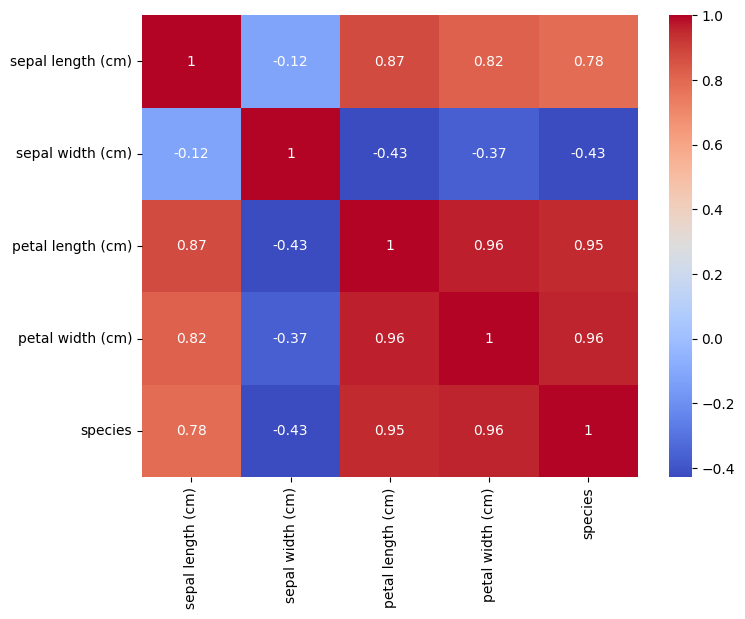

In [8]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Data Preprocessing

In [9]:
# standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[iris.feature_names])

df_scaled = pd.DataFrame(scaled_features, columns=iris.feature_names)
df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [10]:
df_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [11]:
# Normalization
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
normalized = mm.fit_transform(df[iris.feature_names])
df_normalized = pd.DataFrame(normalized, columns=iris.feature_names)
df_normalized.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [12]:
df_normalized.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [13]:
# binning
df["sepal_length_bin"] = pd.cut(df["sepal length (cm)"], bins=3, labels=["short", "medium", "long"])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal_length_bin
0,5.1,3.5,1.4,0.2,0,short
1,4.9,3.0,1.4,0.2,0,short
2,4.7,3.2,1.3,0.2,0,short
3,4.6,3.1,1.5,0.2,0,short
4,5.0,3.6,1.4,0.2,0,short


In [14]:
df[df.sepal_length_bin=="short"]["sepal length (cm)"].describe()

count    59.000000
mean      5.018644
std       0.319738
min       4.300000
25%       4.800000
50%       5.000000
75%       5.200000
max       5.500000
Name: sepal length (cm), dtype: float64

In [15]:
df[df.sepal_length_bin=="medium"]["sepal length (cm)"].describe()

count    71.000000
mean      6.136620
std       0.352639
min       5.600000
25%       5.800000
50%       6.100000
75%       6.400000
max       6.700000
Name: sepal length (cm), dtype: float64

In [16]:
df[df.sepal_length_bin=="long"]["sepal length (cm)"].describe()

count    20.000000
mean      7.235000
std       0.367459
min       6.800000
25%       6.900000
50%       7.200000
75%       7.625000
max       7.900000
Name: sepal length (cm), dtype: float64

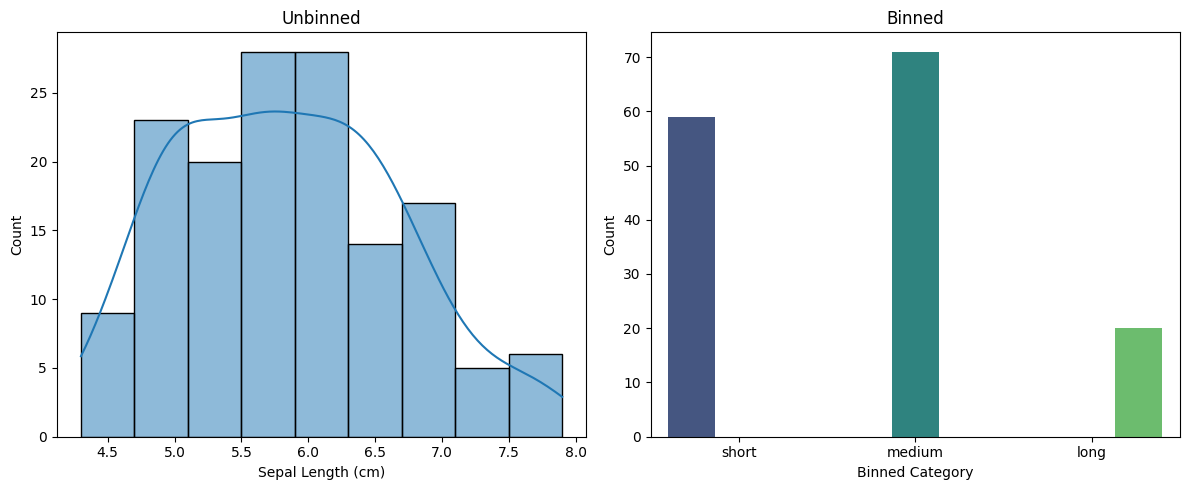

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unbinned continuous distribution
sns.histplot(df["sepal length (cm)"], kde=True, ax=axes[0])
axes[0].set_title("Unbinned")
axes[0].set_xlabel("Sepal Length (cm)")

# Binned categorical distribution
sns.countplot(x=df["sepal_length_bin"], ax=axes[1], palette="viridis", hue=df["sepal_length_bin"], legend=False)
axes[1].set_title("Binned")
axes[1].set_xlabel("Binned Category")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [18]:
# one-hot encoding
df_encoded = pd.get_dummies(df, columns=["sepal_length_bin"])
df_encoded.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal_length_bin_short,sepal_length_bin_medium,sepal_length_bin_long
0,5.1,3.5,1.4,0.2,0,True,False,False
1,4.9,3.0,1.4,0.2,0,True,False,False
2,4.7,3.2,1.3,0.2,0,True,False,False
3,4.6,3.1,1.5,0.2,0,True,False,False
4,5.0,3.6,1.4,0.2,0,True,False,False


#### Feature Engineering

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[iris.feature_names])

pd.DataFrame(poly_features).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,5.1,3.5,1.4,0.2,26.01,17.85,7.14,1.02,12.25,4.90,0.70,1.96,0.28,0.04
1,4.9,3.0,1.4,0.2,24.01,14.70,6.86,0.98,9.00,4.20,0.60,1.96,0.28,0.04
2,4.7,3.2,1.3,0.2,22.09,15.04,6.11,0.94,10.24,4.16,0.64,1.69,0.26,0.04
3,4.6,3.1,1.5,0.2,21.16,14.26,6.90,0.92,9.61,4.65,0.62,2.25,0.30,0.04
4,5.0,3.6,1.4,0.2,25.00,18.00,7.00,1.00,12.96,5.04,0.72,1.96,0.28,0.04


In [20]:
# log transformation
import numpy as np
df_log = df[iris.feature_names].apply(lambda x: np.log(x + 1))
df_log.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,1.808289,1.504077,0.875469,0.182322
1,1.774952,1.386294,0.875469,0.182322
2,1.740466,1.435085,0.832909,0.182322
3,1.722767,1.410987,0.916291,0.182322
4,1.791759,1.526056,0.875469,0.182322


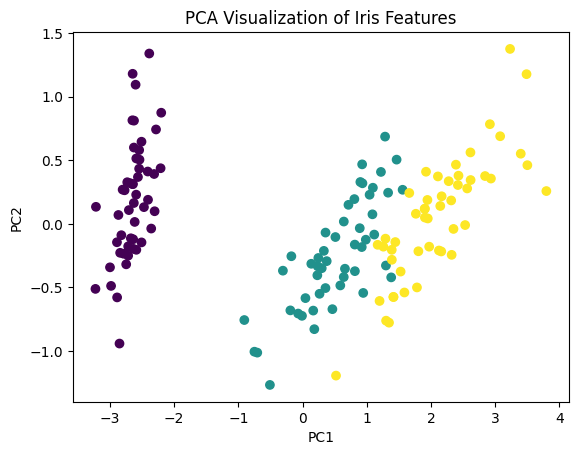

In [21]:
# dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[iris.feature_names])

plt.scatter(pca_result[:,0], pca_result[:,1], c=df["species"], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Iris Features")
plt.show()

**Exercise**
1. Create box plots for each numerical feature in the Iris dataset. Identify potential outliers. How would you deal with them?
2. Randomly convert 10% of the values in two numeric features to missing values. Plot a stacked bar chart showing the number of present and missing values for each feature. Apply two different treatments to the missing values: mean imputation and median imputation. Compare the before/after distributions.
3. Plot side-by-side histograms for one feature after scaling (both standardization and normalization).
4. Create two engineered features. The first feature is a ratio of petal length to sepal length, and the second feature is an interaction term: sepal_width × petal_width. Add them to the dataset and use PCA with 2 components to visualize whether the new features help cluster species better.

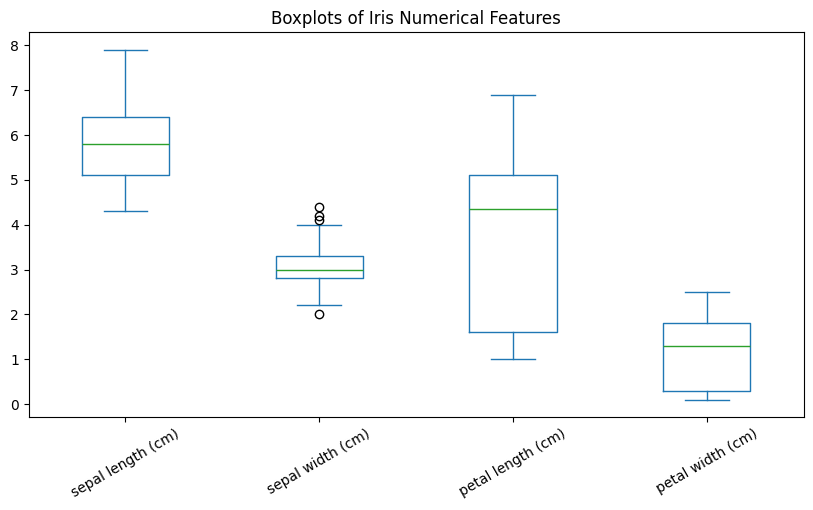

{'sepal length (cm)': 0,
 'sepal width (cm)': 4,
 'petal length (cm)': 0,
 'petal width (cm)': 0}

In [ ]:
# 1. Create box plots for each numerical feature in the Iris dataset. Identify potential outliers. How would you deal with them?

import matplotlib.pyplot as plt

# Get the names of the numeric features
features = iris.feature_names

# -----------------------------
# 1) Plot boxplots
# -----------------------------
df[features].plot(kind="box", figsize=(10,5))

plt.title("Boxplots of Iris Numerical Features")
plt.xticks(rotation=30)
plt.show()


# -----------------------------
# 2) Detect outliers using IQR
# -----------------------------
outlier_summary = {}

for col in features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    
    outlier_summary[col] = len(outliers)

outlier_summary

sepal length (cm)    15
petal width (cm)     15
dtype: int64


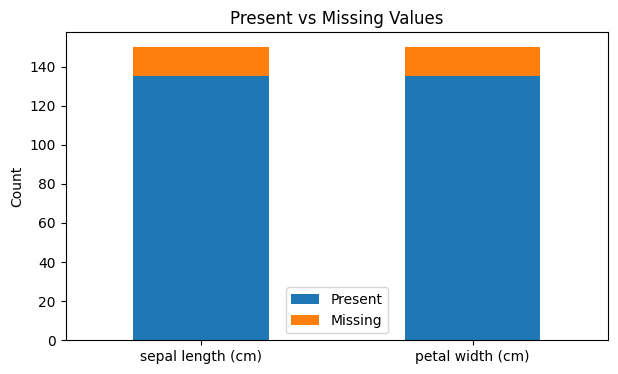

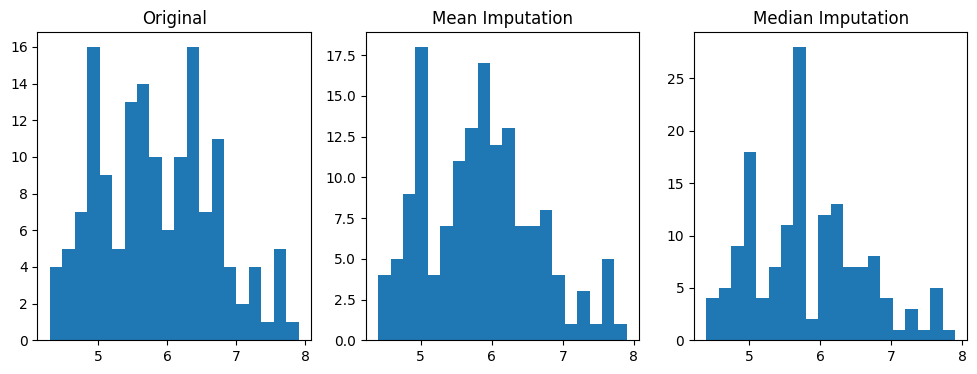

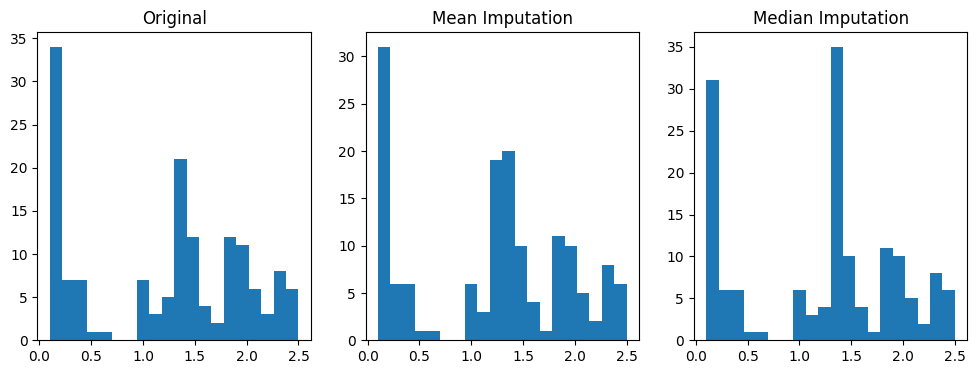

In [ ]:
#2. Randomly convert 10% of the values in two numeric features to missing values. Plot a stacked bar chart showing the number of present and missing values for each feature. 
# Apply two different treatments to the missing values: mean imputation and median imputation. Compare the before/after distributions.

import numpy as np
import matplotlib.pyplot as plt

# Create a random generator
rng = np.random.default_rng(42)

# Make a copy of the dataset
df_missing = df.copy()

# Select two numeric features
cols = ["sepal length (cm)", "petal width (cm)"]

# Total number of rows
n = len(df_missing)

# Introduce 10% missing values randomly
for col in cols:
    idx = rng.choice(n, size=int(0.1*n), replace=False)
    df_missing.loc[idx, col] = np.nan

# Check number of missing values
print(df_missing[cols].isna().sum())


# -----------------------------
# Plot stacked bar chart
# -----------------------------
present = df_missing[cols].notna().sum()
missing = df_missing[cols].isna().sum()

counts = pd.DataFrame({
    "Present": present,
    "Missing": missing
})

counts.plot(kind="bar", stacked=True, figsize=(7,4))

plt.title("Present vs Missing Values")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# -----------------------------
# Mean imputation
# -----------------------------
df_mean = df_missing.copy()

for col in cols:
    mean_value = df_mean[col].mean()
    df_mean[col] = df_mean[col].fillna(mean_value)


# -----------------------------
# Median imputation
# -----------------------------
df_median = df_missing.copy()

for col in cols:
    median_value = df_median[col].median()
    df_median[col] = df_median[col].fillna(median_value)


# -----------------------------
# Compare distributions
# -----------------------------
for col in cols:
    
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.hist(df[col], bins=20)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.hist(df_mean[col], bins=20)
    plt.title("Mean Imputation")

    plt.subplot(1,3,3)
    plt.hist(df_median[col], bins=20)
    plt.title("Median Imputation")

    plt.show()

To handle the missing values, two imputation techniques were applied:

Mean Imputation
Mean imputation replaces missing values with the average value of the feature. This method is simple and commonly used, but it can be affected by outliers.

Median Imputation
Median imputation replaces missing values with the median (middle value) of the feature. This method is more robust to outliers and often preserves the data distribution better.

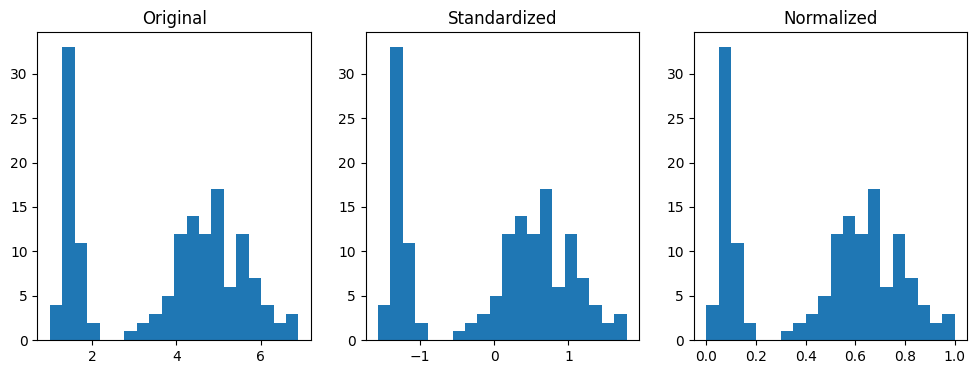

In [ ]:
#3. Plot side-by-side histograms for one feature after scaling (both standardization and normalization).

from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# Choose one feature
feature = df[["petal length (cm)"]]

# Create the scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply scaling
feature_standardized = standard_scaler.fit_transform(feature)
feature_normalized = minmax_scaler.fit_transform(feature)

# Plot histograms side by side
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(feature, bins=20)
plt.title("Original")

plt.subplot(1,3,2)
plt.hist(feature_standardized, bins=20)
plt.title("Standardized")

plt.subplot(1,3,3)
plt.hist(feature_normalized, bins=20)
plt.title("Normalized")

plt.show()

In machine learning, features can have different scales, which may negatively affect model performance. 
Feature scaling helps bring all variables to a comparable range. 
Standardization transforms data so it has a mean of zero and a standard deviation of one using StandardScaler, while normalization rescales values between 0 and 1 using MinMaxScaler. This helps many algorithms learn more effectively.

In this exercise, we applied two feature scaling techniques: standardization and normalization. 
Standardization, implemented using StandardScaler, centers the data around a mean of zero with a standard deviation of one. 
Normalization, implemented using MinMaxScaler, rescales values so they fall between 0 and 1. These techniques help machine learning algorithms perform better by ensuring that features with larger values do not dominate the learning process.

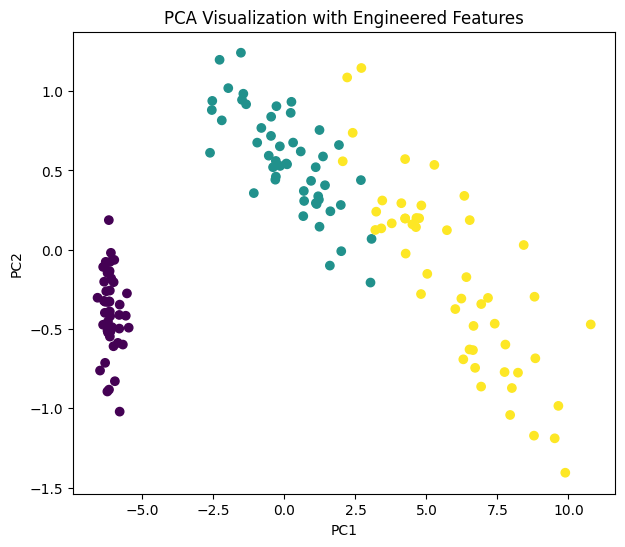

In [ ]:
#4. Create two engineered features. The first feature is a ratio of petal length to sepal length, and the second feature is an interaction term: sepal_width × petal_width. 
# Add them to the dataset and use PCA with 2 components to visualize whether the new features help cluster species better.

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Create engineered features

# Ratio feature
df["petal_to_sepal_ratio"] = df["petal length (cm)"] / df["sepal length (cm)"]

# Interaction feature
df["petal_area"] = df["petal length (cm)"] * df["petal width (cm)"]

# 2. Prepare features for PCA
     
X = df.select_dtypes(include=["number"]) # Select only numeric features
y = df["species"]

# 3. Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)


# 4. Plot the PCA result

plt.figure(figsize=(7,6))

plt.scatter(
    principal_components[:,0],   # PC1
    principal_components[:,1],   # PC2
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization with Engineered Features")

plt.show()

Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique used in machine learning and data analysis. Its goal is to reduce the number of variables in a dataset while preserving as much of the important information (variance) as possible.

PCA works by transforming the original features into a new set of variables called principal components. These components are linear combinations of the original features and are arranged in order of importance.

Key Ideas
Dimensionality Reduction
- PCA reduces many features into fewer components.

Principal Components
- The new variables created by PCA.

~ PC1 captures the largest variation in the data.
~ PC2 captures the second largest variation.

Why PCA is Useful
-  Reduces the complexity of datasets.
-  Helps visualize high-dimensional data in 2D or 3D.
-  Removes redundancy when features are correlated.
-  Can improve machine learning model performance.

Example in the Iris Dataset
In this exercise, PCA is used to reduce multiple numerical features of the Iris dataset into two principal components (PC1 and PC2). These components are then plotted to visualize how well the different iris species cluster together.
